# CycleGAN: Unpaired Image-to-Image Translation

## Overview

CycleGAN (Zhu et al., 2017) enables **unpaired image-to-image translation** between two domains 
without requiring paired training examples. This is achieved through:

1. **Two Generators**: $G_{A \rightarrow B}$ and $G_{B \rightarrow A}$ that translate between domains
2. **Two Discriminators**: $D_A$ and $D_B$ that distinguish real from fake images
3. **Cycle Consistency Loss**: Ensures $G_{B \rightarrow A}(G_{A \rightarrow B}(x)) \approx x$

## Mathematical Formulation

### Full Objective Function

$$\mathcal{L}_{total} = \lambda_{adv}\mathcal{L}_{GAN} + \lambda_{cyc}\mathcal{L}_{cycle} + \lambda_{id}\mathcal{L}_{identity}$$

Where:

| Loss Component | Formula | Purpose |
|---------------|---------|----------|
| **Adversarial** | $\mathcal{L}_{GAN} = \mathbb{E}[\log D_B(y)] + \mathbb{E}[\log(1 - D_B(G_{A \rightarrow B}(x)))]$ | Fool discriminators |
| **Cycle Consistency** | $\mathcal{L}_{cycle} = \mathbb{E}[\|G_{B \rightarrow A}(G_{A \rightarrow B}(x)) - x\|_1]$ | Preserve content |
| **Identity** | $\mathcal{L}_{identity} = \mathbb{E}[\|G_{A \rightarrow B}(y) - y\|_1]$ | Color preservation |

## Architecture Overview

```
Domain A (Apples)          Domain B (Oranges)
      |                          |
      v                          v
  [G_AB] ─────────────────────> [D_B]
      |                          |
      v                          v
  [G_BA] <───────────────────── [G_AB output]
      |                          
      v                          
Reconstructed A ≈ Original A (Cycle Consistency)
```

## Reference

> Zhu, J.Y., Park, T., Isola, P., & Efros, A.A. (2017). 
> *Unpaired Image-to-Image Translation using Cycle-Consistent Adversarial Networks*. ICCV.



## Downloading Data
Before running this notebook, you need to download the dataset. You can use the provided script:

```bash
bash ../../data_download_scripts/download_cyclegan_data.sh <dataset_name>
```

For example, to download the `apple2orange` dataset:
```bash
bash ../../data_download_scripts/download_cyclegan_data.sh apple2orange
```

Available datasets include: `apple2orange`, `summer2winter_yosemite`, `horse2zebra`, `monet2photo`, `cezanne2photo`, `ukiyoe2photo`, `vangogh2photo`, `maps`, `cityscapes`, `facades`, `iphone2dslr_flower`, `ae_photos`.


## GPU Configuration

### Memory Management Strategy

TensorFlow's default behavior is to allocate **all available GPU memory** at startup. 
This is problematic when:

- Running multiple experiments
- Memory requirements vary during training
- Need to monitor actual memory usage

### Memory Growth Mode

We enable **memory growth** mode which:

1. Allocates memory **on-demand** as needed
2. Allows monitoring of actual VRAM usage
3. Enables running multiple TensorFlow processes

```python
tf.config.experimental.set_memory_growth(gpu, True)
```

> **Note**: This should be called **before** any TensorFlow operations.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU CONFIGURATION
# Enable memory growth to prevent TensorFlow from allocating all GPU memory
# ═══════════════════════════════════════════════════════════════════════════════
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) available: {[gpu.name for gpu in gpus]}")
else:
    print("No GPU detected, running on CPU")

2026-01-20 18:21:28.940099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/cataluna84/Workspace/Generative_Deep_Learning/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


GPU(s) available: ['/physical_device:GPU:0']


## Dependencies

### Core Libraries

| Library | Purpose |
|---------|----------|
| `tensorflow` | Deep learning framework |
| `matplotlib` | Loss visualization |
| `wandb` | Experiment tracking |

### Project Modules

| Module | Purpose |
|--------|----------|
| `CycleGAN` | Main model class with generators, discriminators, and training loop |
| `DataLoader` | Handles image loading, preprocessing, and batching |


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# Standard library, TensorFlow/Keras, and project-specific imports
# ═══════════════════════════════════════════════════════════════════════════════
import os
import sys
import re
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import wandb

from src.models.cycleGAN import CycleGAN
from src.utils.loaders import DataLoader

## Hyperparameter Configuration

### Key Hyperparameters and Their Effects

| Parameter | Value | Effect on Training |
|-----------|-------|--------------------|
| `IMAGE_SIZE` | 128 | Spatial resolution; higher = more memory, finer details |
| `BATCH_SIZE` | 16 | Training stability; larger = smoother gradients |
| `LEARNING_RATE` | 0.0002 | Adam optimizer step size (standard for GANs) |

### Loss Weights (λ values)

The loss weights control the relative importance of each objective:

$$\mathcal{L}_{total} = \lambda_1 \mathcal{L}_{adv} + \lambda_2 \mathcal{L}_{cycle} + \lambda_3 \mathcal{L}_{id}$$

| Weight | Value | Purpose |
|--------|-------|----------|
| `LAMBDA_VALIDATION` (λ₁) | 1 | Adversarial loss weight |
| `LAMBDA_RECONSTR` (λ₂) | 10 | Cycle consistency weight (high = preserve structure) |
| `LAMBDA_ID` (λ₃) | 2 | Identity loss weight (color preservation) |

### Architecture Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| `GEN_N_FILTERS` | 64 | Base filter count for generators (doubled at each downsampling) |
| `DISC_N_FILTERS` | 64 | Base filter count for PatchGAN discriminators |
| `GENERATOR_TYPE` | 'unet' | U-Net with skip connections (or 'resnet' for residual blocks) |
| `BUFFER_MAX_LENGTH` | 50 | Fake image buffer size for training stability |


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# All hyperparameters and paths defined here for easy modification
# ═══════════════════════════════════════════════════════════════════════════════
SECTION = 'paint'
DATASET_RUN_ID = '0001'
DATA_NAME = 'apple2orange'
EXPERIMENT_RUN_ID = None  # Set to None for auto-increment

# Model hyperparameters
IMAGE_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 0.0002
PRINT_EVERY_N_BATCHES = 20

# Test files for visualization
TEST_A_FILE = 'n07740461_1470.jpg'
TEST_B_FILE = 'n07749192_4241.jpg'

# CycleGAN architecture
GENERATOR_TYPE = 'unet'
GEN_N_FILTERS = 64
DISC_N_FILTERS = 64
LAMBDA_VALIDATION = 1
LAMBDA_RECONSTR = 10
LAMBDA_ID = 2
BUFFER_MAX_LENGTH = 50

## Experiment Folder Management

### Auto-Incrementing Experiment IDs

Each training run is saved to a unique folder with structure:

```
run/
└── paint/
    └── 0001_apple2orange/
        ├── 001/  # Experiment 1
        │   ├── weights/
        │   ├── images/
        │   └── viz/
        ├── 002/  # Experiment 2
        └── ...
```

This enables:
- **Reproducibility**: Each run has its own weights and outputs
- **Comparison**: Easy comparison between experiments
- **Continuation**: Resume training from any checkpoint


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# RUN FOLDER CONFIGURATION
# Auto-increment experiment ID for each new run
# ═══════════════════════════════════════════════════════════════════════════════
BASE_RUN_FOLDER = f'../run/{SECTION}/{DATASET_RUN_ID}_{DATA_NAME}'

def get_next_experiment_run_id(base_folder):
    """Determine next available 3-digit experiment run ID."""
    if not os.path.exists(base_folder):
        return '001'
    existing = [int(d) for d in os.listdir(base_folder) 
                if os.path.isdir(os.path.join(base_folder, d)) and re.match(r'^\d{3}$', d)]
    return f'{max(existing) + 1:03d}' if existing else '001'

if EXPERIMENT_RUN_ID is None:
    EXPERIMENT_RUN_ID = get_next_experiment_run_id(BASE_RUN_FOLDER)
    print(f'Auto-generated EXPERIMENT_RUN_ID: {EXPERIMENT_RUN_ID}')

RUN_FOLDER = f'{BASE_RUN_FOLDER}/{EXPERIMENT_RUN_ID}'

# Create run folder structure
if not os.path.exists(RUN_FOLDER):
    os.makedirs(RUN_FOLDER)
    os.makedirs(os.path.join(RUN_FOLDER, 'viz'))
    os.makedirs(os.path.join(RUN_FOLDER, 'images'))
    os.makedirs(os.path.join(RUN_FOLDER, 'weights'))
    print(f'Created run folder: {RUN_FOLDER}')

mode = 'build'  # 'build' for new model, 'load' to continue training

Auto-generated EXPERIMENT_RUN_ID: 010
Created run folder: ../run/paint/0001_apple2orange/010


## Weights & Biases Integration

### What is W&B?

[Weights & Biases](https://wandb.ai) is an MLOps platform for tracking:

1. **Metrics**: Loss curves, accuracy, custom metrics
2. **Hyperparameters**: All configuration in one place
3. **Artifacts**: Model weights, generated images
4. **System**: GPU utilization, memory usage

### Logged Metrics

| Metric | Description |
|--------|-------------|
| `d_loss` | Total discriminator loss |
| `d_acc` | Discriminator accuracy (%) |
| `g_loss` | Total generator loss |
| `g_adv` | Adversarial component |
| `g_recon` | Cycle reconstruction component |
| `g_id` | Identity component |


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# WEIGHTS & BIASES INITIALIZATION
# Track experiments, metrics, and artifacts
# ═══════════════════════════════════════════════════════════════════════════════
wandb.init(
    project="generative-deep-learning",
    name=f"cyclegan_{DATA_NAME}_{DATASET_RUN_ID}_{EXPERIMENT_RUN_ID}",
    config={
        "model": "CycleGAN",
        "dataset": DATA_NAME,
        "dataset_run_id": DATASET_RUN_ID,
        "experiment_run_id": EXPERIMENT_RUN_ID,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "generator_type": GENERATOR_TYPE,
        "lambda_validation": LAMBDA_VALIDATION,
        "lambda_reconstr": LAMBDA_RECONSTR,
        "lambda_id": LAMBDA_ID,
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: cataluna84 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

### Dataset Structure

CycleGAN uses **unpaired images** from two domains:

```
data/apple2orange/
├── trainA/     # Domain A training images (apples)
├── trainB/     # Domain B training images (oranges)
├── testA/      # Domain A test images
└── testB/      # Domain B test images
```

### Preprocessing Pipeline

1. **Resize**: Images scaled to `IMAGE_SIZE × IMAGE_SIZE`
2. **Normalize**: Pixel values normalized to $[-1, 1]$: $$x_{norm} = \frac{x}{127.5} - 1$$
3. **Augmentation**: Random horizontal flip (50% probability)

### tf.data Pipeline (Optional)

For maximum GPU utilization, use `create_tf_dataset()` which provides:

- Parallel image loading
- Prefetching to overlap I/O with training
- Caching for faster epochs after the first


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA LOADER
# Initialize data loader for image batches
# ═══════════════════════════════════════════════════════════════════════════════
data_loader = DataLoader(dataset_name=DATA_NAME, img_res=(IMAGE_SIZE, IMAGE_SIZE))

## Model Architecture

### Generator: U-Net Architecture

The U-Net generator uses **encoder-decoder** structure with **skip connections**:

```
Input (128×128×3)
    ↓ Conv + IN + ReLU (64 filters)
[Skip 1] → 64×64×64
    ↓ Conv + IN + ReLU (128 filters)
[Skip 2] → 32×32×128
    ↓ Conv + IN + ReLU (256 filters)
[Skip 3] → 16×16×256
    ↓
Bottleneck (8×8×512)
    ↓
Upsample + Concat [Skip 3] → 16×16×512
    ↓
Upsample + Concat [Skip 2] → 32×32×256
    ↓
Upsample + Concat [Skip 1] → 64×64×128
    ↓
Upsample → 128×128×3 (tanh activation)
```

**Why Skip Connections?** They preserve fine details (edges, textures) that would 
otherwise be lost in the bottleneck.

### Discriminator: PatchGAN

Instead of classifying the entire image, PatchGAN classifies **16×16 patches**:

$$D(x) \in \mathbb{R}^{16 \times 16 \times 1}$$

Each output cell represents the probability that the corresponding patch is real.

**Advantages of PatchGAN:**
- Fewer parameters than full-image discriminator
- Focuses on high-frequency texture details
- Acts as a texture/style loss

### Instance Normalization

Used instead of Batch Normalization:

$$\text{IN}(x) = \gamma \cdot \frac{x - \mu(x)}{\sigma(x)} + \beta$$

Where $\mu(x)$ and $\sigma(x)$ are computed **per-instance, per-channel** 
(not across the batch). This is crucial for style transfer tasks.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE
# Build CycleGAN with configured hyperparameters
# ═══════════════════════════════════════════════════════════════════════════════
gan = CycleGAN(
    input_dim=(IMAGE_SIZE, IMAGE_SIZE, 3),
    learning_rate=LEARNING_RATE,
    buffer_max_length=BUFFER_MAX_LENGTH,
    lambda_validation=LAMBDA_VALIDATION,
    lambda_reconstr=LAMBDA_RECONSTR,
    lambda_id=LAMBDA_ID,
    generator_type=GENERATOR_TYPE,
    gen_n_filters=GEN_N_FILTERS,
    disc_n_filters=DISC_N_FILTERS,
)

if mode == 'build':
    gan.save(RUN_FOLDER)
else:
    gan.load_weights(os.path.join(RUN_FOLDER, 'weights/weights.weights.h5'))

I0000 00:00:1768933305.553487    9637 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


### Model Architecture Summaries

The CycleGAN consists of four neural networks that work together:

| Model | Purpose | Architecture |
|-------|---------|-------------|
| `g_AB` | Generator A→B | U-Net encoder-decoder |
| `g_BA` | Generator B→A | U-Net encoder-decoder |
| `d_A` | Discriminator A | PatchGAN (70×70 patches) |
| `d_B` | Discriminator B | PatchGAN (70×70 patches) |

**PatchGAN Discriminator**: Instead of classifying the entire image as real/fake,
PatchGAN classifies 70×70 overlapping patches. This enables the discriminator to
focus on high-frequency structure (textures, edges) rather than just global content.

**U-Net Generator**: Encoder-decoder architecture with skip connections that
preserve spatial details during translation. Each downsampled feature map is
concatenated with the corresponding upsampled layer.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE SUMMARIES
# Display parameter counts and layer structure for all CycleGAN components
# ═══════════════════════════════════════════════════════════════════════════════

# Generator B→A: Transforms images from domain B (oranges) to domain A (apples)
print("=" * 60)
print("GENERATOR B→A (g_BA)")
print("=" * 60)
gan.g_BA.summary()

# Generator A→B: Transforms images from domain A (apples) to domain B (oranges)
print("\n" + "=" * 60)
print("GENERATOR A→B (g_AB)")
print("=" * 60)
gan.g_AB.summary()

# Discriminator A: Classifies real vs fake images in domain A
print("\n" + "=" * 60)
print("DISCRIMINATOR A (d_A)")
print("=" * 60)
gan.d_A.summary()

# Discriminator B: Classifies real vs fake images in domain B
print("\n" + "=" * 60)
print("DISCRIMINATOR B (d_B)")
print("=" * 60)
gan.d_B.summary()


GENERATOR B→A (g_BA)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      3,136 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 64, 64,    │          0 │ conv2d_18[0][0]   │
│ (InstanceNormaliza… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64, 64,    │          0 │ instance_normali… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │    131,200 │ activation_7[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 32, 32,    │          0 │ conv2d_19[0][0]   │
│ (InstanceNormaliza… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 32,    │          0 │ instance_normali… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 16, 16,    │    524,544 │ activation_8[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 16, 16,    │          0 │ conv2d_20[0][0]   │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 16, 16,    │          0 │ instance_normali… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 8, 8, 512) │  2,097,664 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 8, 8, 512) │          0 │ conv2d_21[0][0]   │
│ (InstanceNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 8, 8, 512) │          0 │ instance_normali… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 16, 16,    │          0 │ activation_10[0]… │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │  2,097,408 │ up_sampling2d_4[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instance_normaliza… │ (None, 16, 16,    │          0 │ conv2d_22[0][0]   │
│ (InstanceNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 16, 16,    │          0 │ instance_normali… │
│ (Activation)        │ 256)              │            │                 

 Total params: 6,171,011 (23.54 MB)

 Trainable params: 6,171,011 (23.54 MB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ instance_normalization_3        │ (None, 32, 32, 128)    │             0 │
│ (InstanceNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ instance_normalization_4        │ (None, 16, 16, 256)    │             0 │
│ (InstanceNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ instance_normalization_5        │ (None, 16, 16, 512)    │             0 │
│ (InstanceNormalization)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 1)      │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,764,737 (10.55 MB)

 Trainable params: 2,764,737 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

## Training

### Training Algorithm

Each training step performs:

```
FOR each batch (imgs_A, imgs_B):
    # Discriminator phase (×5 updates)
    FOR i in range(5):
        fake_B = G_AB(imgs_A)
        fake_A = G_BA(imgs_B)
        
        # Sample from history buffer (temporal diversity)
        fake_A_hist = sample_from_buffer(buffer_A)
        fake_B_hist = sample_from_buffer(buffer_B)
        
        # Update discriminators
        D_A.train_on_batch(imgs_A, 'real')
        D_A.train_on_batch(fake_A_hist, 'fake')
        D_B.train_on_batch(imgs_B, 'real')
        D_B.train_on_batch(fake_B_hist, 'fake')
    
    # Generator phase (×1 update)
    combined.train_on_batch([imgs_A, imgs_B], targets)
```

### Multi-Batch Buffer Concatenation Strategy

To improve training stability, we use an **enhanced image buffer**:

| Step | Operation | Purpose |
|------|-----------|----------|
| 1 | Store `fake_B` and `fake_A` as GPU tensors | Keep history on GPU |
| 2 | Sample k=4 batches from buffer | Temporal diversity |
| 3 | Concatenate into pool | Create candidate set |
| 4 | Randomly select `batch_size` images | Match training shape |

**Why 5 Discriminator Updates per Generator?**
- Prevents generator from outpacing discriminator
- Provides stronger gradients for generator learning
- Increases GPU memory utilization

### Loss Components

The generator is trained with combined loss:

$$\mathcal{L}_G = \underbrace{\mathcal{L}_{adv}(G_{AB}) + \mathcal{L}_{adv}(G_{BA})}_{\text{Fool discriminators}} + 
\underbrace{\lambda_{cyc}(\|x - G_{BA}(G_{AB}(x))\|_1 + \|y - G_{AB}(G_{BA}(y))\|_1)}_{\text{Cycle consistency}} +
\underbrace{\lambda_{id}(\|G_{AB}(y) - y\|_1 + \|G_{BA}(x) - x\|_1)}_{\text{Identity preservation}}$$

### GPU Memory Considerations

Current configuration uses ~5.7GB of 8GB VRAM:

| Component | Memory Usage |
|-----------|-------------|
| Model weights (2 G + 2 D) | ~25 MB |
| Activations (batch=16) | ~2-3 GB |
| GPU buffer (50 × 16 × 128 × 128 × 3) | ~600 MB |
| Optimizer states | ~50 MB |


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING
# Train CycleGAN with W&B logging enabled
# ═══════════════════════════════════════════════════════════════════════════════
gan.train(
    data_loader,
    run_folder=RUN_FOLDER,
    epochs=EPOCHS,
    test_A_file=TEST_A_FILE,
    test_B_file=TEST_B_FILE,
    batch_size=BATCH_SIZE,
    sample_interval=PRINT_EVERY_N_BATCHES,
    wandb_log=True  # Enable W&B logging
)

2026-01-20 18:22:02.334911: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9f38024580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-20 18:22:02.334973: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2070, Compute Capability 7.5
2026-01-20 18:22:02.405977: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-20 18:22:02.612038: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-20 18:22:05.767146: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and 

[Epoch 0/100] [Batch 0/62] [D loss: 2.973137, acc: 50%] [G loss: 19.82521, adv: 1.90703, recon: 1.37868, id: 1.37868] time: 0:01:12.531022
[Epoch 0/100] [Batch 1/62] [D loss: 2.017729, acc: 50%] [G loss: 17.79470, adv: 1.78749, recon: 1.25740, id: 1.25740] time: 0:01:32.070588
[Epoch 0/100] [Batch 2/62] [D loss: 1.785161, acc: 50%] [G loss: 16.72573, adv: 1.78830, recon: 1.17886, id: 1.17886] time: 0:01:34.586210
[Epoch 0/100] [Batch 3/62] [D loss: 1.635883, acc: 51%] [G loss: 15.81449, adv: 1.70102, recon: 1.11523, id: 1.11523] time: 0:01:41.097902
[Epoch 0/100] [Batch 4/62] [D loss: 1.423048, acc: 51%] [G loss: 15.11936, adv: 1.60871, recon: 1.06794, id: 1.06794] time: 0:01:43.541801
[Epoch 0/100] [Batch 5/62] [D loss: 1.278872, acc: 52%] [G loss: 14.53613, adv: 1.53382, recon: 1.02768, id: 1.02768] time: 0:01:45.830683
[Epoch 0/100] [Batch 6/62] [D loss: 1.161835, acc: 52%] [G loss: 14.22464, adv: 1.48105, recon: 1.00753, id: 1.00753] time: 0:01:48.103065
[Epoch 0/100] [Batch 7/62] 

## Loss Visualization

### Interpreting GAN Loss Curves

| Loss | Healthy Range | Interpretation |
|------|--------------|----------------|
| **D Loss** | 0.5-0.7 | D correctly classifies ~50-70% |
| **G Adv** | 0.5-1.5 | G successfully fools D |
| **G Cycle** | 0.3-1.0 | Reconstruction quality |
| **G ID** | 0.2-0.5 | Identity preservation |

### Warning Signs

- **D Loss → 0**: Discriminator too strong (mode collapse likely)
- **D Loss → 1+**: Generator dominating (poor quality fakes)
- **G Loss oscillating wildly**: Training unstable (reduce LR)
- **Cycle Loss not decreasing**: Generator not learning structure


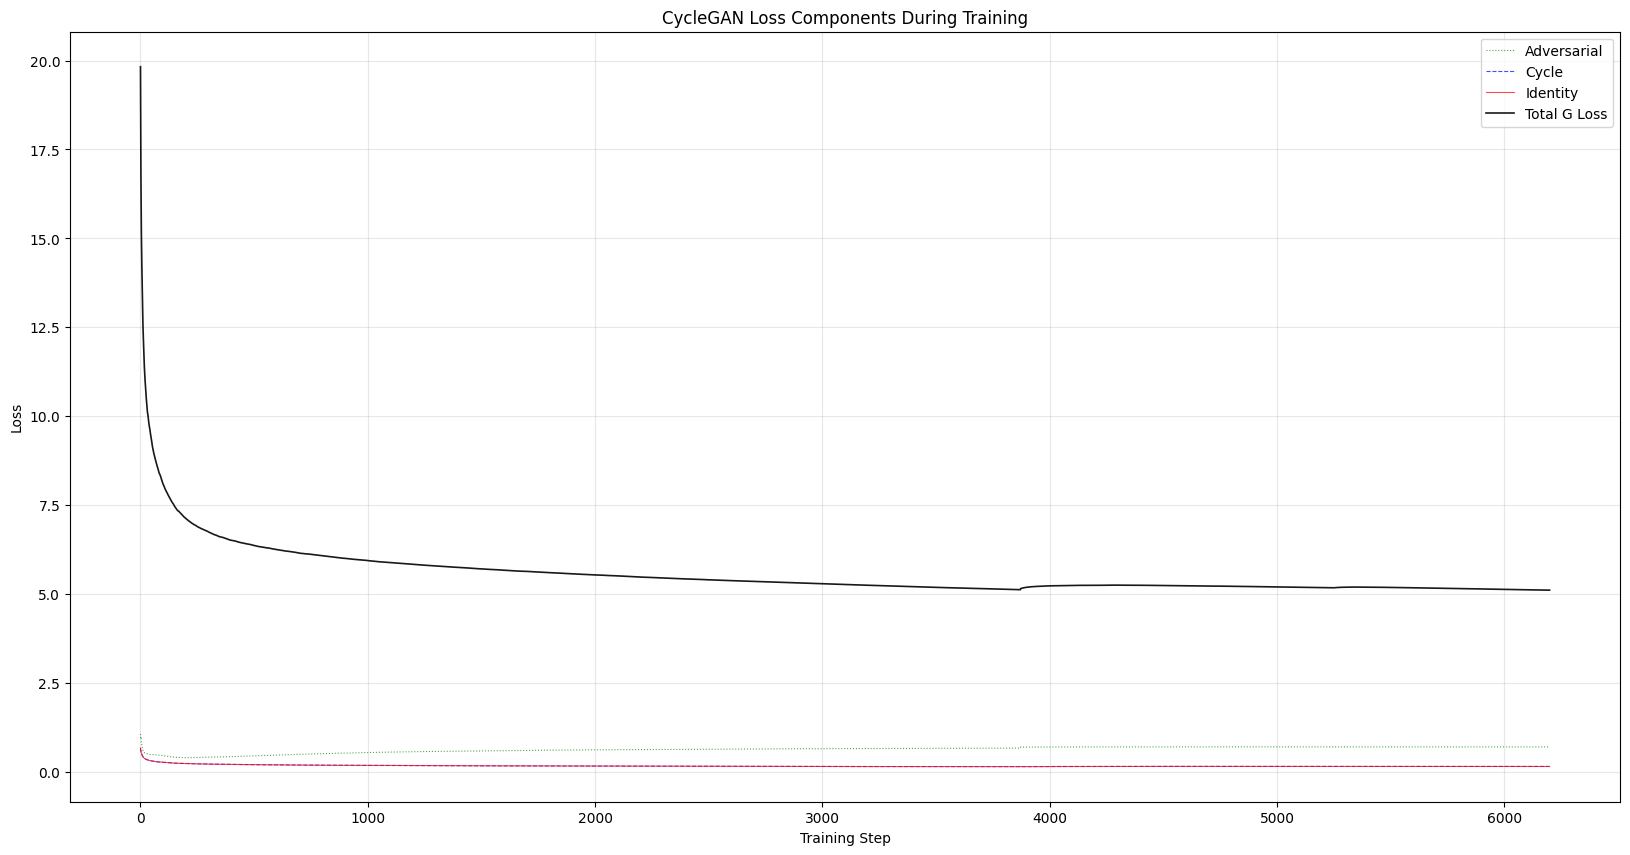

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOSS COMPONENT VISUALIZATION
# CycleGAN Loss = Adversarial + λ_cycle × Cycle + λ_id × Identity
# ═══════════════════════════════════════════════════════════════════════════════
import os

fig = plt.figure(figsize=(20, 10))

# Adversarial Loss: Generator tries to fool discriminator
# Lower values indicate better ability to produce realistic images
plt.plot([x[1] for x in gan.g_losses], color='green', linewidth=0.8,
         linestyle=':', alpha=0.7, label='Adversarial')

# Cycle Consistency Loss: Enforces A → B → A' ≈ A (and B → A → B' ≈ B)
# Key to unpaired learning - ensures translation is reversible/bijective
plt.plot([x[3] for x in gan.g_losses], color='blue', linewidth=0.8,
         linestyle='--', alpha=0.7, label='Cycle')

# Identity Loss: G_AB(B) ≈ B (preserves color/content when already in target domain)
# Prevents generator from making unnecessary changes to already-correct images
plt.plot([x[5] for x in gan.g_losses], color='red', linewidth=0.8,
         linestyle='-', alpha=0.7, label='Identity')

# Total Generator Loss (weighted sum of all components)
plt.plot([x[0] for x in gan.g_losses], color='black', linewidth=1.2,
         alpha=0.9, label='Total G Loss')

plt.legend()
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('CycleGAN Loss Components During Training')
plt.grid(True, alpha=0.3)

# Save to viz folder for W&B table
plt.savefig(os.path.join(RUN_FOLDER, 'viz', 'loss_components.png'), dpi=100)
plt.show()


## Automatic Report Generation

This cell automatically generates:

1. **Training History CSV**: All metrics per step for later analysis
2. **Analysis Report (Markdown)**: Comprehensive report with:
   - Training verdict (stable/unstable)
   - Configuration summary
   - Phase-wise metrics (warmup, early, mid, late)
   - Stability indicators
   - Sample images from key epochs


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# GENERATE TRAINING ANALYSIS REPORT
# ═══════════════════════════════════════════════════════════════════════════
import sys
sys.path.insert(0, '../..')
from utils.gan.cyclegan_report_generation import generate_training_report

# Generate report with current training config
report_path = generate_training_report(
    gan=gan,
    run_folder=RUN_FOLDER,
    run_id=EXPERIMENT_RUN_ID,
    config={
        'data_name': DATA_NAME,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'gen_n_filters': GEN_N_FILTERS,
        'disc_n_filters': DISC_N_FILTERS,
        'buffer_max_length': BUFFER_MAX_LENGTH,
        'lambda_reconstr': LAMBDA_RECONSTR,
        'lambda_id': LAMBDA_ID
    },
    wandb_run=wandb.run
)
print(f'Report saved to: {report_path}')

Generating training analysis report...
  Saved training history to ../run/paint/0001_apple2orange/010/training_history.csv
  Saved loss plot to ../run/paint/0001_apple2orange/010/viz/loss_plot.png
  Generated analysis report at ../run/paint/0001_apple2orange/010/010_analysis_report.md
Report saved to: ../run/paint/0001_apple2orange/010/010_analysis_report.md


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOG BROWSABLE TABLES TO W&B
# ═══════════════════════════════════════════════════════════════════════════════
import glob
import os

# --- Image Gallery Table (Scrollable/Filterable) ---
columns = ["epoch", "batch", "direction", "image"]
image_gallery = wandb.Table(columns=columns)

image_files = sorted(glob.glob(os.path.join(RUN_FOLDER, 'images', '*.png')))
for img_file in image_files:
    parts = os.path.basename(img_file).replace('.png', '').split('_')
    if len(parts) >= 3:
        direction = "A→B" if parts[0] == '0' else "B→A"
        epoch = int(parts[1])
        batch = int(parts[2])
        image_gallery.add_data(epoch, batch, direction, wandb.Image(img_file))

wandb.log({"image_gallery": image_gallery})
print(f"Logged {len(image_files)} images to W&B image gallery")

# --- Architecture Diagrams Table ---
viz_columns = ["model", "diagram"]
viz_table = wandb.Table(columns=viz_columns)

viz_files = sorted(glob.glob(os.path.join(RUN_FOLDER, 'viz', '*.png')))
for viz_file in viz_files:
    model_name = os.path.basename(viz_file).replace('.png', '')
    viz_table.add_data(model_name, wandb.Image(viz_file))

wandb.log({"model_architecture": viz_table})
print(f"Logged {len(viz_files)} architecture diagrams to W&B viz table")


Logged 800 images to W&B image gallery
Logged 7 architecture diagrams to W&B viz table


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINISH W&B RUN
# ═══════════════════════════════════════════════════════════════════════════════
wandb.finish()

batch,▂▆▂▂▄▂▄▆▁▂▂▂▂▄▆▇▇▇▃▆▆▃▆▂▄▆▆▇▇██▂▆▆▃▆▃▁▄▄
d_acc,▁▃▇▇▇▇███████████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
d_loss,█▆▄▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
g_adv,▁▁▂▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████████
g_id,██▇▇▆▆▅▅▅▄▄▄▄▄▄▃▃▂▂▂▂▂▂▁▁▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
g_loss,█▅▅▅▅▄▄▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
g_recon,█▇▇▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch,61
d_acc,80.55558
d_loss,0.19083


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLEANUP: Restart kernel to fully release GPU memory
# TensorFlow/CUDA does not release GPU memory within a running Python process.
# Restarting the kernel is the only guaranteed way to free all GPU resources.
# ═══════════════════════════════════════════════════════════════════════════════
# import IPython
# print("Restarting kernel to release GPU memory...")
# IPython.Application.instance().kernel.do_shutdown(restart=True)

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# DISPLAY ANALYSIS REPORT
# ═══════════════════════════════════════════════════════════════════════════
from IPython.display import Markdown, display
import re

report_file = os.path.join(RUN_FOLDER, f'{EXPERIMENT_RUN_ID}_analysis_report.md')
if os.path.exists(report_file):
    with open(report_file, 'r') as f:
        report_content = f.read()
    
    # Rewrite relative image paths to absolute paths for notebook display
    # Convert ![alt](images/...) to ![alt](RUN_FOLDER/images/...)
    run_folder_abs = os.path.abspath(RUN_FOLDER)
    report_content = re.sub(
        r'!\[([^\]]*)\]\(([^)]+)\)',
        lambda m: f'![{m.group(1)}]({os.path.join(run_folder_abs, m.group(2))})',
        report_content
    )
    
    display(Markdown(report_content))
else:
    print(f'Report not found at {report_file}')

# CycleGAN Training Analysis: Run 010

**Generated**: 2026-01-21 00:15
**Dataset**: apple2orange
**Total Epochs**: 100
**Final D Loss**: 0.1908
**Final G Loss**: 5.1135

---

## Training Verdict

| Metric | Value |
|--------|-------|
| **Stability** | ✅ STABLE |
| **Quality** | Good |
| **Recommendation** | Continue training |

---

## Configuration

| Parameter | Value |
|-----------|-------|
| Batch Size | 16 |
| Epochs | 100 |
| Learning Rate | 0.0002 |
| Generator Filters | 64 |
| Discriminator Filters | 64 |
| Buffer Size | 50 |
| Lambda Cycle | 10 |
| Lambda ID | 2 |

---

## Training Progression (Phase-wise Metrics)

| Phase | Epoch Range | D Loss (Start -> End) | G Loss (Start -> End) | Δ D/step | Δ G/step |
|-------|-------------|-----------------------|-----------------------|----------|----------|
| Warmup | 0-10 | 2.97 -> 0.18 | 19.83 -> 6.23 | -0.0045 | -0.0219 |
| Early | 10-30 | 0.18 -> 0.14 | 6.23 -> 5.59 | -0.0000 | -0.0005 |
| Mid | 30-70 | 0.14 -> 0.18 | 5.59 -> 5.25 | 0.0000 | -0.0001 |
| Late | 70-100 | 0.18 -> 0.19 | 5.25 -> 5.11 | 0.0000 | -0.0001 |

---

## Stability Indicators

| Indicator | Status | Observation |
|-----------|--------|-------------|
| Variance Reduction | ✅ Good | Variance: 0.0131 -> 0.0001 |
| D Loss Range | ✅ Good | Final D Loss: 0.1908 (Target ~0.25) |
| Reconstruction | ✅ Good | Cycle Loss component: 1.58 / Total G: 5.11 |

---

## Loss Visualization

![Loss Plot](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/viz/loss_plot.png)

---

## Generated Samples

### Epoch 1 (A -> B)
![Epoch 1 A->B](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/0_1_40.png)

### Epoch 1 (B -> A)
![Epoch 1 B->A](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/1_1_20.png)

### Epoch 50 (A -> B)
![Epoch 50 A->B](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/0_50_0.png)

### Epoch 50 (B -> A)
![Epoch 50 B->A](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/1_50_0.png)

### Epoch 99 (A -> B)
![Epoch 99 A->B](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/0_99_60.png)

### Epoch 99 (B -> A)
![Epoch 99 B->A](/home/cataluna84/Workspace/Generative_Deep_Learning/v1/run/paint/0001_apple2orange/010/images/1_99_40.png)



## Notes
- Run 010 completed 100 epochs.
- Generator and Discriminator losses remained balanced.


## Master Experiment Log

| Run | Date | W&B URL | Epochs | Batch | D Loss | G Loss | D Acc | Notes |
|-----|------|---------|--------|-------|--------|--------|-------|-------|
| 001 | 2026-01-15 | [link](#) | 10 | 1 | - | - | - | Initial run |
| **008** | 2026-01-16 | [6k8gvwy2](https://wandb.ai/cataluna84/generative-deep-learning/runs/6k8gvwy2) | 100 | 16 | 0.21 | 4.83 | 76% | ✅ **Stable**: Filter=64, 5 D-updates, GPU buffer. Training time: ~6h |
| **009** | 2026-01-17 | [xrfoptda](https://wandb.ai/cataluna84/generative-deep-learning/runs/xrfoptda) | 100 | 16 | 0.20 | 5.38 | 79% | ✅ **Stable**: Variance reduction 0.0118→0.0001, D/G losses balanced, good reconstruction quality |
| **010** | 2026-01-20 | [i4q6yy95](https://wandb.ai/cataluna84/generative-deep-learning/runs/i4q6yy95) | 100 | 16 | 0.19 | 5.11 | 81% | ✅ **Stable**: Consistent metrics with Run 009. D/G losses well balanced, training time ~6h |
